In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def create_dataset(seq_length=5, total_samples=1000):
    X = []
    y = []
    for _ in range(total_samples):
        start = np.random.rand()
        seq = np.array([start + i*0.1 for i in range(seq_length+1)])
        X.append(seq[:-1])
        y.append(seq[-1])
    return np.array(X), np.array(y)

seq_length = 5
X, y = create_dataset(seq_length)

# reshape for RNN input: (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))
y = y.reshape((-1, 1))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 5, 1)
y shape: (1000, 1)


In [ ]:
df = pd.DataFrame(X.reshape(-1, seq_length),
                  columns=[f"x_{i}" for i in range(seq_length)])
df["y"] = y
df.head()

,x_0,x_1,x_2,x_3,x_4,y
0,0.376910,0.476910,0.576910,0.676910,0.776910,0.876910
1,0.016797,0.116797,0.216797,0.316797,0.416797,0.516797
2,0.622131,0.722131,0.822131,0.922131,1.022131,1.122131
3,0.962160,1.062160,1.162160,1.262160,1.362160,1.462160
4,0.153604,0.253604,0.353604,0.453604,0.553604,0.653604


In [ ]:
def build_rnn_model():
  model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(units=15,
                             activation='tanh',
                             input_shape=(seq_length, 1)
                             ),
    tf.keras.layers.Dense(units=1)
  ])
  model.compile(optimizer='adam', loss='mse', metrics=['mse'])
  return model

model = build_rnn_model()
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 15)             │           255 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271 (1.06 KB)

 Trainable params: 271 (1.06 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_rnn = model.fit(
    X, y,
    epochs=5,
    batch_size=32,
    verbose=1,
    validation_split=0.2
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.2327 - mse: 0.2327 - val_loss: 0.0215 - val_mse: 0.0215
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0228 - mse: 0.0228 - val_loss: 0.0159 - val_mse: 0.0159
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0132 - mse: 0.0132 - val_loss: 0.0119 - val_mse: 0.0119
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0097 - mse: 0.0097 - val_loss: 0.0085 - val_mse: 0.0085
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0073 - mse: 0.0073 - val_loss: 0.0065 - val_mse: 0.0065


In [ ]:
pred_rnn= model.predict(X[:10])
# print("predictions:",pred_rnn)
# print("actual:", y[:10])

#convert this to dataframe
df_pred = pd.DataFrame(pred_rnn, columns=["prediction"])
df_pred["actual"] = y[:10]
df_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


,prediction,actual
0,0.960514,0.876910
1,0.445652,0.516797
2,1.149800,1.122131
3,1.276747,1.462160
4,0.679146,0.653604
5,1.271550,1.437801
6,0.621251,0.617097
7,0.472357,0.531269
8,0.568229,0.585374
9,1.005401,0.924133


In [ ]:
255*4

1020

In [ ]:
def build_lstm_model():
  model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(units=15,
                             input_shape=(seq_length, 1)
                             ),
    tf.keras.layers.Dense(units=1)
  ])
  model_lstm.compile(optimizer='adam', loss='mse', metrics=['mse'])
  return model_lstm

model_lstm = build_lstm_model()
model_lstm.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 15)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,036 (4.05 KB)

 Trainable params: 1,036 (4.05 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm = model_lstm.fit(
    X, y,
    epochs=5,
    batch_size=32,
    verbose=1,
    validation_split=0.2
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.4940 - mse: 0.4940 - val_loss: 0.2919 - val_mse: 0.2919
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1324 - mse: 0.1324 - val_loss: 0.0239 - val_mse: 0.0239
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0045 - mse: 0.0045 - val_loss: 0.0022 - val_mse: 0.0022
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.0412e-04 - mse: 9.0412e-04 - val_loss: 3.0929e-04 - val_mse: 3.0929e-04
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8607e-04 - mse: 2.8607e-04 - val_loss: 2.4152e-04 - val_mse: 2.4152e-04


In [ ]:
pred_lstm= model_lstm.predict(X[:10])
# print("predictions:",pred_lstm)
# print("actual:", y[:10])
#convert this to dataframe
df_pred = pd.DataFrame(pred_lstm, columns=["prediction"])
df_pred["actual"] = y[:10]
df_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


,prediction,actual
0,0.889962,0.876910
1,0.515168,0.516797
2,1.132173,1.122131
3,1.421000,1.462160
4,0.657164,0.653604
5,1.402455,1.437801
6,0.619008,0.617097
7,0.530027,0.531269
8,0.585974,0.585374
9,0.938189,0.924133


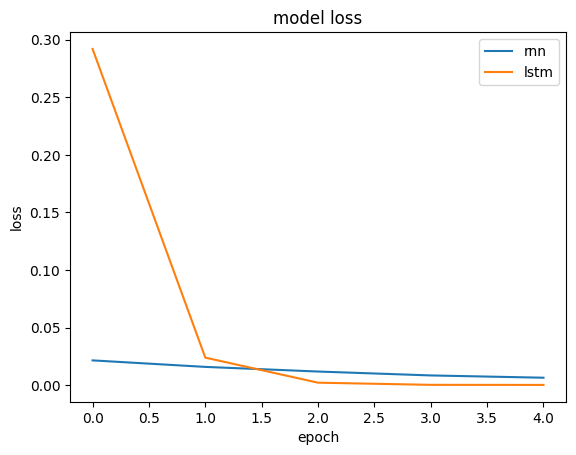

In [ ]:
plt.plot(history_rnn.history['val_loss'], label='rnn')
plt.plot(history_lstm.history['val_loss'], label='lstm')
plt.legend()
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()